## Here is the evaluation coding section for the diagrams

In [2]:
import json

with open("cognitive_nodes_clean.json", "r", encoding="utf-8") as f:
    cognitive_nodes = json.load(f)

with open("behaviour_graph.json", "r", encoding="utf-8") as f:
    behaviour_graph = json.load(f)


In [3]:
#Exrtacting the cognitive reasoning text here:
cog_texts = []
cog_ids = []

for node in cognitive_nodes["nodes"]:
    if node.get("role") == "LLM":
        text = str(node.get("full", "")).strip()
        if text:
            cog_texts.append(text)
            cog_ids.append(node.get("id"))

print("Cognitive LLM reasoning units extracted:", len(cog_texts))
print("Cognitive IDs:", cog_ids)


# Extracting the behavioural reasoning text (LLM only)

beh_texts = []
beh_ids = []

for node in behaviour_graph["nodes"]:
    if node.get("type") == "llm":
        text = str(node.get("text", "")).strip()
        if text:
            beh_texts.append(text)
            beh_ids.append(node.get("id"))

print("Behaviour LLM reasoning units extracted:", len(beh_texts))
print("Behaviour IDs:", beh_ids)


Cognitive LLM reasoning units extracted: 15
Cognitive IDs: ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10', 'L12', 'L13', 'L14', 'L15']
Behaviour LLM reasoning units extracted: 11
Behaviour IDs: ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10']


In [4]:
import re
import nltk
from nltk import word_tokenize, pos_tag
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

ACTION_VERBS = {
    "inspect","analyse","analyze","explore","examine","compare","evaluate",
    "calculate","compute","check","understand","identify","determine",
    "visualise","visualize","test","assess","investigate","review","summarise",
    "summarize","interpret","study","measure","look","consider"
}


DOMAIN_NOUNS = {
    "age","sex","cp","trestbps","chol","cholesterol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target",
    "distribution","correlation","outliers","groups","group",
    "missing","values","dataset","data","trend","risk","difference",
    "classification","test","mann","whitney","chi","square","hypothesis"
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def extract_action_verbs(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    verbs = [w for w, pos in tagged if pos.startswith("VB")]
    
    return [v for v in verbs if v in ACTION_VERBS]

def extract_nouns(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    nouns = [w for w, pos in tagged if pos.startswith("NN")]
   
    return [n for n in nouns if n in DOMAIN_NOUNS]


def extract_action_units(text):
    cleaned = clean_text(text)
    verbs = extract_action_verbs(cleaned)
    nouns = extract_nouns(cleaned)

    action_units = []
    for v in verbs:
        
        for n in nouns:
            action_units.append((v, n))

   
    if not nouns:
        for v in verbs:
            action_units.append((v, None))

    return action_units

[nltk_data] Downloading package punkt to C:\Users\Rakeen
[nltk_data]     Afser\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Rakeen Afser\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [5]:

cognitive_text = {cid: text for cid, text in zip(cog_ids, cog_texts)}

print("Cognitive dictionary created with", len(cognitive_text), "entries.")

cognitive_actions = {}

for cid, text in cognitive_text.items():
    actions = extract_action_units(text)
    cognitive_actions[cid] = actions

for cid, acts in cognitive_actions.items():
    print(f"\nCognitive Node {cid} — {len(acts)} action units:")
    for a in acts:
        print("   ", a)

print("\nCognitive action extraction complete.")


Cognitive dictionary created with 15 entries.

Cognitive Node L0 — 45 action units:
    ('inspect', 'dataset')
    ('inspect', 'dataset')
    ('inspect', 'data')
    ('inspect', 'values')
    ('inspect', 'dataset')
    ('inspect', 'data')
    ('inspect', 'dataset')
    ('inspect', 'data')
    ('inspect', 'dataset')
    ('check', 'dataset')
    ('check', 'dataset')
    ('check', 'data')
    ('check', 'values')
    ('check', 'dataset')
    ('check', 'data')
    ('check', 'dataset')
    ('check', 'data')
    ('check', 'dataset')
    ('understand', 'dataset')
    ('understand', 'dataset')
    ('understand', 'data')
    ('understand', 'values')
    ('understand', 'dataset')
    ('understand', 'data')
    ('understand', 'dataset')
    ('understand', 'data')
    ('understand', 'dataset')
    ('analyse', 'dataset')
    ('analyse', 'dataset')
    ('analyse', 'data')
    ('analyse', 'values')
    ('analyse', 'dataset')
    ('analyse', 'data')
    ('analyse', 'dataset')
    ('analyse', 'data')
  

In [6]:

behaviour_text = {bid: text for bid, text in zip(beh_ids, beh_texts)}

print("Behaviour dictionary created with", len(behaviour_text), "entries.")


behaviour_actions = {}

for bid, text in behaviour_text.items():
    actions = extract_action_units(text)
    behaviour_actions[bid] = actions


for bid, acts in behaviour_actions.items():
    print(f"\nBehaviour Node {bid} — {len(acts)} action units:")
    for a in acts:
        print("   ", a)

print("\nBehaviour action extraction complete.")


Behaviour dictionary created with 11 entries.

Behaviour Node L0 — 48 action units:
    ('explore', 'dataset')
    ('explore', 'age')
    ('explore', 'age')
    ('explore', 'sex')
    ('explore', 'cp')
    ('explore', 'trestbps')
    ('explore', 'chol')
    ('explore', 'cholesterol')
    ('explore', 'fbs')
    ('explore', 'restecg')
    ('explore', 'thalach')
    ('explore', 'oldpeak')
    ('explore', 'slope')
    ('explore', 'slope')
    ('explore', 'thal')
    ('explore', 'target')
    ('explore', 'correlation')
    ('explore', 'age')
    ('explore', 'risk')
    ('explore', 'cholesterol')
    ('explore', 'target')
    ('explore', 'exang')
    ('explore', 'chi')
    ('explore', 'test')
    ('explore', 'dataset')
    ('explore', 'age')
    ('explore', 'age')
    ('explore', 'sex')
    ('explore', 'cp')
    ('explore', 'trestbps')
    ('explore', 'chol')
    ('explore', 'cholesterol')
    ('explore', 'fbs')
    ('explore', 'restecg')
    ('explore', 'thalach')
    ('explore', 'oldpeak')

In [7]:

VERB_MAP = {
    "identify":   ["assess", "explore", "compare", "test", "visualize", "analyze"],
    "inspect":    ["explore", "look", "check"],
    "understand": ["explore", "visualize", "analyze", "compare"],
    "consider":   ["explore", "assess", "check"],
    "interpret":  ["explore", "evaluate", "visualize", "analyze", "compare"],
    "evaluate":   ["assess", "compare", "test", "visualize", "analyze"],
    "look":       ["look", "explore", "visualize"],
    "explore":    ["explore", "look", "visualize"],
    "compare":    ["compare", "test"],
    "assess":     ["assess", "evaluate", "analyze"],
}


VERB_NORMALIZE = {
    "analyse": "analyze",
    "analyze": "analyze",
    "visualise": "visualize",
    "visualize": "visualize"
}




GENERAL_NOUNS = {"dataset", "data", "values"}  


RISK_NOUNS = {"risk", "cp", "chol", "cholesterol", "thalach", "sex", "age", "bp"}
GROUP_NOUNS = {"group", "groups", "target"}
DIST_NOUNS = {"distribution", "newpeak", "oldpeak", "range", "test", "trend"}


def noun_category(noun):
    if noun in GENERAL_NOUNS:
        return "general"
    if noun in RISK_NOUNS:
        return "risk"
    if noun in GROUP_NOUNS:
        return "group"
    if noun in DIST_NOUNS:
        return "distribution"
    return "other"  


print("Semantic verb and noun mappings loaded.")


Semantic verb and noun mappings loaded.


In [8]:

def normalize_verb(v):
    """Normalize verbs to canonical forms."""
    return VERB_NORMALIZE.get(v, v)  


def verbs_match(cog_verb, beh_verb):
    """
    Check if cognitive verb matches behaviour verb semantically.
    """
    cog_verb = normalize_verb(cog_verb)
    beh_verb = normalize_verb(beh_verb)


    if cog_verb == beh_verb:
        return True

   
    if cog_verb in VERB_MAP:
        if beh_verb in VERB_MAP[cog_verb]:
            return True

    return False


def nouns_match(cog_noun, beh_noun):
    """
    Determine if cognitive noun matches behaviour noun semantically.
    """

    
    if cog_noun in GENERAL_NOUNS:
        return True

 
    cog_cat = noun_category(cog_noun)
    beh_cat = noun_category(beh_noun)

    if cog_cat != "other" and cog_cat == beh_cat:
        return True

   
    if cog_noun == beh_noun:
        return True

    return False


def actions_semantically_match(cog_action, beh_action):
    """
    Returns True if cognitive action semantically aligns with behaviour action.
    """
    cog_verb, cog_noun = cog_action
    beh_verb, beh_noun = beh_action

   
    if not verbs_match(cog_verb, beh_verb):
        return False

    
    if not nouns_match(cog_noun, beh_noun):
        return False

    return True


print("Semantic matching functions loaded.")


Semantic matching functions loaded.


In [9]:

import pandas as pd

alignment_rows = []

beh_order = list(behaviour_actions.keys())

def find_semantic_match(cog_action):
    """
    For a given cognitive action (verb, noun), find the
    earliest behaviour action that semantically matches.
    """
    for bid in beh_order:
        for beh_act in behaviour_actions[bid]:
            if actions_semantically_match(cog_action, beh_act):
                return bid, beh_act

    return None, None  



for cid, cog_acts in cognitive_actions.items():
    for cog_act in cog_acts:

        beh_id, beh_act = find_semantic_match(cog_act)

        alignment_rows.append({
            "Cognitive_ID": cid,
            "Cognitive_Action": cog_act,
            "Matched_Behaviour_ID": beh_id,
            "Matched_Behaviour_Action": beh_act,
            "Executed": beh_id is not None
        })

alignment_df = pd.DataFrame(alignment_rows)

print("Semantic alignment complete.")
alignment_df.head(15)


Semantic alignment complete.


,Cognitive_ID,Cognitive_Action,Matched_Behaviour_ID,Matched_Behaviour_Action,Executed
0,L0,"(inspect, dataset)",L0,"(explore, dataset)",True
1,L0,"(inspect, dataset)",L0,"(explore, dataset)",True
2,L0,"(inspect, data)",L0,"(explore, dataset)",True
3,L0,"(inspect, values)",L0,"(explore, dataset)",True
4,L0,"(inspect, dataset)",L0,"(explore, dataset)",True
5,L0,"(inspect, data)",L0,"(explore, dataset)",True
6,L0,"(inspect, dataset)",L0,"(explore, dataset)",True
7,L0,"(inspect, data)",L0,"(explore, dataset)",True
8,L0,"(inspect, dataset)",L0,"(explore, dataset)",True
9,L0,"(check, dataset)",L4,"(check, oldpeak)",True


In [10]:

execution_summary = (
    alignment_df
    .groupby("Cognitive_ID")
    .agg(
        Planned_Actions=("Executed", "count"),
        Executed_Actions=("Executed", "sum")
    )
)


execution_summary["Execution_Rate_%"] = (
    execution_summary["Executed_Actions"] / execution_summary["Planned_Actions"] * 100
).round(2)

print("Execution metrics computed.")
execution_summary


Execution metrics computed.


,Planned_Actions,Executed_Actions,Execution_Rate_%
Cognitive_ID,,,
L0,45,45,100.00
L1,48,44,91.67
L10,64,64,100.00
L12,120,112,93.33
L13,28,28,100.00
L14,21,18,85.71
L15,14,14,100.00
L2,60,60,100.00
L3,75,75,100.00


In [11]:

all_cog_actions = set(cog_action for actions in cognitive_actions.values() for cog_action in actions)


def find_unaligned_behaviour_actions():
    """Return behaviour actions that do not align with ANY cognitive action."""
    unaligned = []

    for bid, beh_acts in behaviour_actions.items():
        for beh_act in beh_acts:

            # Check if this behaviour act matches ANY cognitive act
            matched = any(
                actions_semantically_match(cog_act, beh_act)
                for cog_act in all_cog_actions
            )

            if not matched:
                unaligned.append({
                    "Behaviour_ID": bid,
                    "Behaviour_Action": beh_act
                })

    return pd.DataFrame(unaligned)


unaligned_behaviour_df = find_unaligned_behaviour_actions()

print("Behaviour-only (unplanned) actions identified.")
unaligned_behaviour_df.head(20)


Behaviour-only (unplanned) actions identified.


,Behaviour_ID,Behaviour_Action
0,L6,"(compute, hypothesis)"
1,L6,"(compute, values)"
2,L6,"(compute, distribution)"
3,L6,"(compute, hypothesis)"
4,L6,"(compute, hypothesis)"
5,L6,"(compute, group)"
6,L6,"(compute, target)"
7,L6,"(compute, values)"
8,L6,"(compute, group)"
9,L6,"(compute, target)"


In [12]:

all_behaviour_actions = [
    beh_act
    for acts in behaviour_actions.values()
    for beh_act in acts
]

def cognitive_actions_not_executed():
    """Return cognitive actions that have no matching behaviour action."""
    unexecuted = []

    for cid, cog_acts in cognitive_actions.items():
        for cog_act in cog_acts:

           
            matched = any(
                actions_semantically_match(cog_act, beh_act)
                for beh_act in all_behaviour_actions
            )

            if not matched:
                unexecuted.append({
                    "Cognitive_ID": cid,
                    "Cognitive_Action": cog_act
                })

    return pd.DataFrame(unexecuted)


unexecuted_cognitive_df = cognitive_actions_not_executed()

print("Unexecuted cognitive actions identified.")
unexecuted_cognitive_df.head(20)


Unexecuted cognitive actions identified.


,Cognitive_ID,Cognitive_Action
0,L1,"(identify, outliers)"
1,L1,"(check, outliers)"
2,L1,"(consider, outliers)"
3,L1,"(understand, outliers)"
4,L4,"(interpret, classification)"
5,L4,"(inspect, classification)"
6,L7,"(check, trestbps)"
7,L7,"(check, trestbps)"
8,L7,"(check, outliers)"
9,L7,"(compare, trestbps)"


In [13]:

unexecuted_counts = (
    unexecuted_cognitive_df
    .groupby("Cognitive_ID")
    .size()
    .rename("Unexecuted_Actions")
)


unexpected_counts = (
    unaligned_behaviour_df
    .groupby("Behaviour_ID")
    .size()
    .rename("Unexpected_Behaviour_Actions")
)


evaluation_summary = pd.concat([unexecuted_counts, unexpected_counts], axis=1).fillna(0)


evaluation_summary["Unexecuted_Actions"] = evaluation_summary["Unexecuted_Actions"].astype(int)
evaluation_summary["Unexpected_Behaviour_Actions"] = evaluation_summary["Unexpected_Behaviour_Actions"].astype(int)

evaluation_summary


,Unexecuted_Actions,Unexpected_Behaviour_Actions
L1,4,0
L12,8,0
L14,3,0
L4,2,0
L7,19,0
L8,4,0
L6,0,27


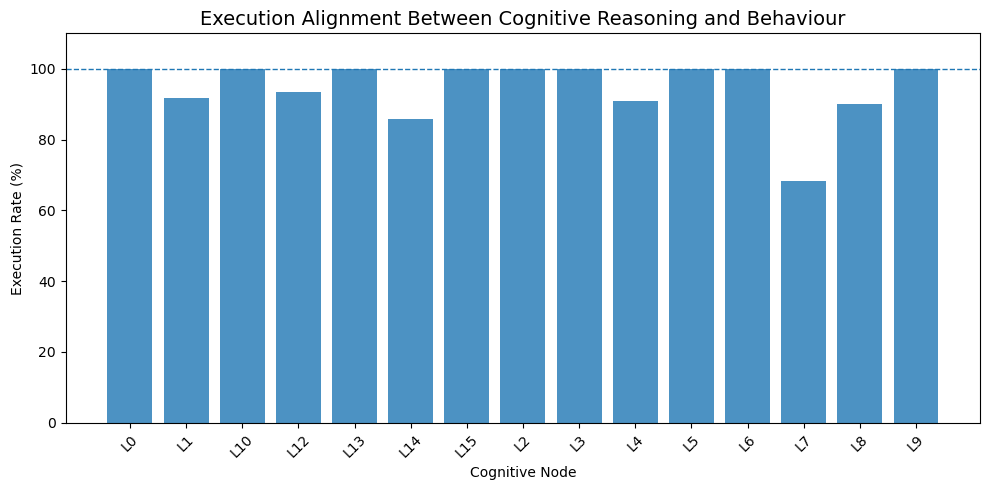

In [14]:


import matplotlib.pyplot as plt


exec_df = execution_summary.reset_index()  

plt.figure(figsize=(10, 5))

plt.bar(exec_df["Cognitive_ID"], exec_df["Execution_Rate_%"], alpha=0.8)

plt.title("Execution Alignment Between Cognitive Reasoning and Behaviour", fontsize=14)
plt.ylabel("Execution Rate (%)")
plt.xlabel("Cognitive Node")

plt.ylim(0, 110)
plt.axhline(100, linestyle="--", linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


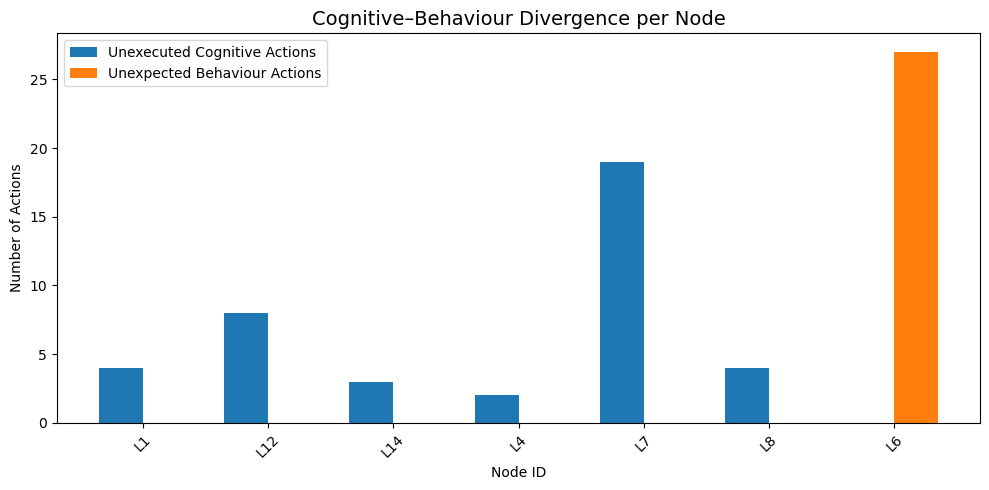

In [15]:


import matplotlib.pyplot as plt
import numpy as np


unexec_counts = (
    unexecuted_cognitive_df
    .groupby("Cognitive_ID")
    .size()
    .rename("Unexecuted")
)


unexpected_counts = (
    unaligned_behaviour_df
    .groupby("Behaviour_ID")
    .size()
    .rename("Unexpected")
)


div_df = pd.concat([unexec_counts, unexpected_counts], axis=1).fillna(0).astype(int)

plt.figure(figsize=(10, 5))

x = np.arange(len(div_df.index))
width = 0.35

plt.bar(x - width/2, div_df["Unexecuted"], width, label="Unexecuted Cognitive Actions")
plt.bar(x + width/2, div_df["Unexpected"], width, label="Unexpected Behaviour Actions")

plt.title("Cognitive–Behaviour Divergence per Node", fontsize=14)
plt.xlabel("Node ID")
plt.ylabel("Number of Actions")

plt.xticks(x, div_df.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
